Normal at 0: {'pH': 6.89, 'turbidity': 59.97, 'pH_norm': 0.4633333333333332, 'turbidity_norm': 0.5997}
ML Model Activated at 1: {'pH': 5.55, 'turbidity': 30.36, 'pH_norm': 0.016666666666666607, 'turbidity_norm': 0.3036}
ML Model Activated at 2: {'pH': 5.86, 'turbidity': 25.88, 'pH_norm': 0.1200000000000001, 'turbidity_norm': 0.2588}
Normal at 3: {'pH': 7.78, 'turbidity': 38.21, 'pH_norm': 0.7600000000000001, 'turbidity_norm': 0.3821}
Normal at 4: {'pH': 7.63, 'turbidity': 54.61, 'pH_norm': 0.71, 'turbidity_norm': 0.5461}
Normal at 5: {'pH': 6.86, 'turbidity': 2.78, 'pH_norm': 0.4533333333333334, 'turbidity_norm': 0.0278}
ML Model Activated at 6: {'pH': 7.26, 'turbidity': 94.53, 'pH_norm': 0.5866666666666666, 'turbidity_norm': 0.9453}
Normal at 7: {'pH': 8.27, 'turbidity': 55.12, 'pH_norm': 0.9233333333333332, 'turbidity_norm': 0.5512}
Normal at 8: {'pH': 7.88, 'turbidity': 44.59, 'pH_norm': 0.7933333333333333, 'turbidity_norm': 0.4459}
Normal at 9: {'pH': 6.11, 'turbidity': 58.74, 'pH_

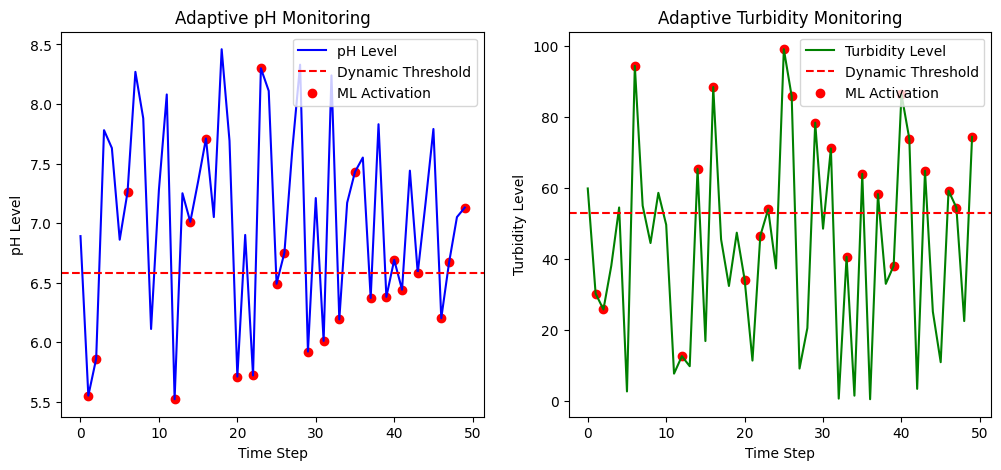

In [ ]:
# Install Required Libraries
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Initialize Dynamic Thresholds & Buffer for Incremental Learning
dynamic_pH_threshold = 6.0
dynamic_turbidity_threshold = 80.0
sensor_buffer = []

# Generate Simulated Sensor Data
def read_sensor():
    return {"pH": round(random.uniform(5.5, 8.5), 2), "turbidity": round(random.uniform(0, 100), 2)}

# Normalize Sensor Readings
def preprocess(data):
    data["pH_norm"] = (data["pH"] - 5.5) / (8.5 - 5.5)
    data["turbidity_norm"] = data["turbidity"] / 100
    return data

# Activate ML Model Based on Dynamic Thresholds
def trigger_ml(data):
    return data["pH"] < dynamic_pH_threshold or data["turbidity"] > dynamic_turbidity_threshold

# Adapt Thresholds Based on Sensor Trends
def adjust_thresholds(pH_values, turbidity_values):
    global dynamic_pH_threshold, dynamic_turbidity_threshold
    dynamic_pH_threshold = max(5.5, np.mean(pH_values) - 0.5)
    dynamic_turbidity_threshold = min(100, np.mean(turbidity_values) + 10)

# Track ML Efficiency
ml_activation_count = 0
total_cycles = 50
timestamps, pH_values, turbidity_values, activation_flags = [], [], [], []

# Load Pre-Trained TinyML Model
model = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Simulate Sensor Data Processing with Event-Based Activation
for i in range(total_cycles):
    sensor_data = read_sensor()
    sensor_data = preprocess(sensor_data)

    timestamps.append(i)
    pH_values.append(sensor_data["pH"])
    turbidity_values.append(sensor_data["turbidity"])
    sensor_buffer.append([sensor_data["pH_norm"], sensor_data["turbidity_norm"]])

    if trigger_ml(sensor_data):
        ml_activation_count += 1  # Count active ML inference cycles
        activation_flags.append(1)
        print(f"ML Model Activated at {i}: {sensor_data}")
    else:
        activation_flags.append(0)
        print(f"Normal at {i}: {sensor_data}")

    if i % 10 == 0 and i > 0:
        adjust_thresholds(pH_values, turbidity_values)
        print(f"Adjusted Thresholds ➝ pH: {dynamic_pH_threshold:.2f}, Turbidity: {dynamic_turbidity_threshold:.2f}")

        # Incremental Learning Update (Retrain Model on Latest Data)
        X_train = np.array(sensor_buffer[-20:])
        y_train = (X_train[:, 0] < 0.3) | (X_train[:, 1] > 0.8)

        model.fit(X_train, y_train, epochs=5, batch_size=4, verbose=0)
        print("Incremental learning update completed.")

    time.sleep(2)

# Compute ML Efficiency Ratio
efficiency_ratio = (ml_activation_count / total_cycles) * 100
print(f" Battery Efficiency: ML ran only {efficiency_ratio:.2f}% of the time, optimizing processing!")

# Visualization of Sensor Trends & Adaptive ML Activation
plt.figure(figsize=(12, 5))

# pH Trend with ML Activation Markers
plt.subplot(1, 2, 1)
plt.plot(timestamps, pH_values, label="pH Level", color="blue")
plt.axhline(y=dynamic_pH_threshold, color='r', linestyle='--', label="Dynamic Threshold")
plt.scatter([timestamps[i] for i in range(len(activation_flags)) if activation_flags[i] == 1],
            [pH_values[i] for i in range(len(activation_flags)) if activation_flags[i] == 1],
            color='red', marker='o', label="ML Activation")
plt.xlabel("Time Step")
plt.ylabel("pH Level")
plt.title("Adaptive pH Monitoring")
plt.legend()

# Turbidity Trend with ML Activation Markers
plt.subplot(1, 2, 2)
plt.plot(timestamps, turbidity_values, label="Turbidity Level", color="green")
plt.axhline(y=dynamic_turbidity_threshold, color='r', linestyle='--', label="Dynamic Threshold")
plt.scatter([timestamps[i] for i in range(len(activation_flags)) if activation_flags[i] == 1],
            [turbidity_values[i] for i in range(len(activation_flags)) if activation_flags[i] == 1],
            color='red', marker='o', label="ML Activation")
plt.xlabel("Time Step")
plt.ylabel("Turbidity Level")
plt.title("Adaptive Turbidity Monitoring")
plt.legend()

plt.show()


In [ ]:
import tensorflow as tf
from tensorflow import keras

# Generate Synthetic Training Data
X_train = np.random.rand(500, 2)  # pH & turbidity normalized
y_train = (X_train[:, 0] < 0.3) | (X_train[:, 1] > 0.8)  # Contamination labels

# Define TinyML Model
model = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
model.fit(X_train, y_train, epochs=50, batch_size=16)


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7210 - loss: 0.6889
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8249 - loss: 0.6851
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8154 - loss: 0.6823
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8031 - loss: 0.6793
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7825 - loss: 0.6768
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8287 - loss: 0.6700
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8041 - loss: 0.6650
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8353 - loss: 0.6570
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8240 - loss: 0.6523
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8281 - loss: 0.6427
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7946 - loss: 0.6418
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8321 - lo

In [ ]:
# Convert model to TensorFlow Lite (.tflite)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save model locally
with open("water_quality_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TinyML Model Converted and Ready for Deployment!")


Saved artifact at '/tmp/tmp9fzo7aas'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137145503022928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137145503022544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137145503019472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137145502116240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137145502115664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137145502117392: TensorSpec(shape=(), dtype=tf.resource, name=None)
TinyML Model Converted and Ready for Deployment!
